<a href="https://colab.research.google.com/github/Haniaakanwal/Deep/blob/main/Deep_Quiz_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# CELL 1 — Upload photo
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)

Saving gettyimages-2285069406-612x612.jpg to gettyimages-2285069406-612x612.jpg
Uploaded: gettyimages-2285069406-612x612.jpg


In [2]:
# CELL 2 — Install dependencies
!pip install opencv-python-headless numpy segment-anything -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth


In [30]:

# CELL 3 — Load model + detect + filter + save crops
import cv2
import numpy as np
import os, shutil
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cuda" if __import__("torch").cuda.is_available() else "cpu")

mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,
    pred_iou_thresh=0.9,
    stability_score_thresh=0.95,
    min_mask_region_area=5000,
)

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(img_rgb)

H, W = img.shape[:2]
out_dir = "crops_sam"
if os.path.exists(out_dir):
    shutil.rmtree(out_dir)
os.makedirs(out_dir)

# --- Stage 1: keep only receipt-sized masks ---
candidates = [m for m in masks if 0.015 * H * W < m["area"] < 0.35 * H * W]


def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]
    return inter / float(areaA + areaB - inter + 1e-6)


def contains(boxA, boxB, thresh=0.85):
    """True if boxB sits mostly inside boxA (sub-element, not its own receipt)."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaB = boxB[2] * boxB[3]
    return inter / float(areaB + 1e-6) > thresh


def has_content(crop, std_thresh=15):
    """Reject blank/uniform crops (background slivers, shadows)."""
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    return gray.std() > std_thresh


# --- Stage 2: remove duplicate / nested masks ---
candidates.sort(key=lambda m: m["area"], reverse=True)
final = []
for m in candidates:
    box = [int(v) for v in m["bbox"]]
    skip = False
    for f in final:
        fbox = [int(v) for v in f["bbox"]]
        if iou(box, fbox) >= 0.5 or contains(fbox, box):
            skip = True
            break
    if not skip:
        final.append(m)

# --- Stage 3: drop size outliers (small internal elements, stamps, icons) ---
if final:
    areas = [m["area"] for m in final]
    median_area = np.median(areas)
    final = [m for m in final if m["area"] > 0.35 * median_area]

# --- Stage 4: drop blank/uniform crops (background slivers) ---
verified = []
for m in final:
    x, y, w, h = [int(v) for v in m["bbox"]]
    crop = img[y:y + h, x:x + w]
    if has_content(crop):
        verified.append(m)
final = verified

# --- Stage 5: drop overly thin slivers (edge shadows/folds) ---
shaped = []
for m in final:
    x, y, w, h = [int(v) for v in m["bbox"]]
    aspect = min(w, h) / max(w, h)
    if aspect > 0.15:
        shaped.append(m)
final = shaped

# --- Save crops + visualization ---
vis = img.copy()
for i, m in enumerate(final):
    x, y, w, h = [int(v) for v in m["bbox"]]
    crop = img[y:y + h, x:x + w]
    cv2.imwrite(f"{out_dir}/receipt_{i}.jpg", crop)
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 3)

cv2.imwrite(f"{out_dir}/detections_visualized.jpg", vis)
print(f"Found {len(final)} receipts")


Found 5 receipts


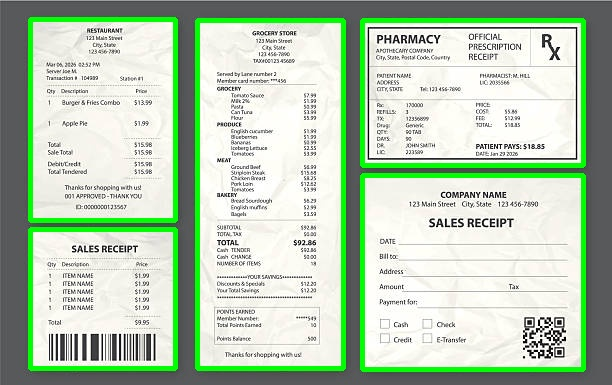

In [31]:

# CELL 4 — View result
from google.colab.patches import cv2_imshow
cv2_imshow(cv2.imread(f"{out_dir}/detections_visualized.jpg"))

In [32]:

# CELL 5 — Download all crops as a zip
!zip -r crops_sam.zip crops_sam -q
from google.colab import files
files.download("crops_sam.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>